In [1]:
!pip install jax[cuda13_pip]==0.9.0.1
!pip install jaxlib==0.9.0.1

In [5]:
import math
import os
from collections import namedtuple
from datetime import datetime
from functools import partial
import io
import itertools
from base64 import b64decode
from typing import List, Optional, Sequence, Tuple
from einops import rearrange
import flax.linen as nn
import flax.linen as nn
from IPython.display import HTML, Image, clear_output
import jax
print(jax.__version__)
from jax import grad
from jax.lax import conv_general_dilated_patches
import jax.numpy as jnp
import jax.random as random
from jax.tree_util import tree_leaves, tree_map
from matplotlib import colors
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import matplotlib.style as style
from matplotlib.ticker import MaxNLocator
import numpy as np
import optax
import PIL
import PIL.Image, PIL.ImageDraw, PIL.ImageFont, PIL.ImageOps
import requests

jax.clear_caches()

0.9.0.1


In [9]:
TrainState = namedtuple('TrainState', 'param opt_state key')
import os
# os.environ['XLA_FLAGS'] = ' --xla_gpu_deterministic_ops=true'
os.environ['FFMPEG_BINARY'] = 'ffmpeg'



# =============================================================================
# DLCA / DiffLogic CA — Fully Commented Reference
# =============================================================================
# This file contains:
#   1) Visualization utilities (numpy/PIL/matplotlib)  [NOT JAX]
#   2) Differentiable logic gate network core:
#        - wiring generation (random / unique / first_kernel)
#        - gate operation library (16 2-input Boolean ops, relaxed to [0,1])
#        - soft vs hard decoding of gates
#        - init + forward for "perceive" and "update" networks
#   3) Cellular automaton rollout:
#        - extract 3x3 Moore patches from an NxN grid
#        - run circuit per patch via vmap
#        - sync vs async update
#        - iterate for num_steps via lax.scan
#   4) Training scaffolding (optax) + loss/grad step
#
# NOTE: The code mixes JAX and NumPy/Matplotlib.
# - Anything using jnp/jax is meant to be JIT-compiled / accelerated.
# - Anything using np/plt/PIL is *Python-side* and not JIT’d.
# =============================================================================

# If using Flax for softmax:
# import flax.linen as nn
# If not using Flax, you can replace nn.softmax with jax.nn.softmax.

# For training
# import optax
# from collections import namedtuple

# =============================================================================
# Constants you referenced but didn’t include in your snippet
# =============================================================================
# These must exist for init_gates / run_async / gate decoding.
NUMBER_OF_GATES = 16

# “Pass-through gate”: typically the identity gate, meaning output = A (or B).
# In your 16-gate list, index 3 corresponds to 'A'. That’s a common pass-through.
PASS_THROUGH_GATE = 3

# Large positive => softmax strongly favors pass-through initially.
DEFAULT_PASS_VALUE = 10.0

# Async CA fire rate: probability a cell updates per step (asynchronous update).
"""
Fire rate for asynchronicity.

60% of cells will perform the update,
40% will have the update masked.
"""
FIRE_RATE = 0.6

TARGET_SIZE = 16
TARGET_EMOJI = "🦎"
TARGET_SIZE_EMOJI = 20
TARGET_SIZE_G = 16

In [10]:
# =============================================================================
# 1) Visualization utilities (NOT part of the model; safe to separate/delete)
# =============================================================================

def zoom(img, scale=4):
  """
  Nearest-neighbor zoom for visualization.
  - Repeats rows and columns `scale` times using NumPy.
  - Useful for making small grids readable as images.
  """
  img = np.repeat(img, scale, 0)
  img = np.repeat(img, scale, 1)
  return img


def load_byte(byte, max_size=TARGET_SIZE):
  """
  Load an RGBA image from raw bytes and normalize to float32 [0,1].
  - Uses PIL to decode and thumbnail.
  - Premultiplies RGB by Alpha (common for compositing).
    i.e. RGB <- RGB * A so transparent pixels don’t “bleed” color.
  """
  img = PIL.Image.open(io.BytesIO(byte))
  img.thumbnail((max_size, max_size), PIL.Image.LANCZOS)
  img = np.float32(img) / 255.0
  img[..., :3] *= img[..., 3:]  # premultiply RGB by Alpha
  return img


def visualize(frames, namefile, size, negate=1):
  """
  Save a list/array of frames as an animated GIF.
  - frames: sequence of 2D arrays (H,W) or (H,W,1)
  - negate: if True, maps x -> 1-x (helpful for binary images)
  """
  fig, ax = plt.subplots(figsize=(size, size))
  ax.set_xticks([])
  ax.set_yticks([])

  def animate(frame):
    ax.clear()
    ax.set_xticks([])
    ax.set_yticks([])
    if negate:
      frame = 1 - frame
    return [ax.imshow(frame, cmap='binary')]

  anim = animation.FuncAnimation(fig, animate, frames=frames, interval=200, blit=True)
  writer = animation.PillowWriter(fps=2)
  anim.save(namefile, writer=writer)
  plt.close()


def plot_show(img, negate=1):
  """
  Convenience plot for a single frame.
  - negate to invert background/foreground for readability.
  """
  if negate:
    img = 1 - img
  fig, ax = plt.subplots(1, 1, figsize=(5, 5))
  ax.imshow(img, cmap='binary')
  ax.axis('off')
  plt.tight_layout()
  plt.show()


def plot_hist_gates(net, save_path=None, title='Distribution of Gates (Sorted)'):
  """
  Plot histogram of gate types used in a network after hard decoding.
  - net: typically an integer array of gate IDs (0..15)
  - Uses np.bincount to count gate usage.
  - Sorted barh plot so rare/common gates are easy to see.

  Note: this is *analysis tooling*, not needed for training/inference.
  """
  gate_types = [
      'FALSE',
      'AND',
      'A AND (NOT B)',
      'A',
      '(NOT A) AND B',
      'B',
      'XOR',
      'OR',
      'NOR',
      'XNOR',
      'NOT B',
      'A OR (NOT B)',
      'NOT A',
      '(NOT A) OR B',
      'NAND',
      'TRUE',
  ]

  gate_counts = np.bincount(net, minlength=len(gate_types))
  sorted_indices = np.argsort(gate_counts)
  sorted_counts = gate_counts[sorted_indices]
  sorted_gate_types = [gate_types[i] for i in sorted_indices]

  fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
  ax.barh(sorted_gate_types, sorted_counts, alpha=0.7, edgecolor='white', linewidth=1)

  ax.set_xlabel('#Gates', fontsize=12, fontweight='bold')
  ax.set_ylabel('Type of gate', fontsize=12, fontweight='bold')
  ax.set_title(title, fontsize=14, fontweight='bold', pad=20)

  ax.grid(True, linestyle='--', alpha=0.7, axis='x')
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  ax.xaxis.set_major_locator(MaxNLocator(integer=True))

  plt.tight_layout()
  if save_path:
    with open(save_path, 'wb') as f:
      plt.savefig(f, format='svg')
  plt.show()


def plot_training_progress(loss_train, loss_test, compute_every, save_path=None):
  """
  Plot training loss curves.
  - loss_train: recorded often (every step)
  - loss_test: recorded more sparsely (every compute_every steps)
  - Designed for showing “soft gate loss” vs “hard decoded loss”.
  """
  fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
  ax.grid(True, linestyle='--', alpha=0.7)

  ax.plot(loss_train, linewidth=2, label='Soft Gates Loss', alpha=0.9)

  ax.plot(
      np.arange(0, len(loss_train), compute_every),
      loss_test,
      linestyle='--',
      linewidth=2,
      label='Hard Gates Loss',
      alpha=0.9,
  )

  ax.set_xlabel('Training Steps', fontsize=12, fontweight='bold')
  ax.set_ylabel('Loss Value', fontsize=12, fontweight='bold')
  ax.set_title('Training Progress - Soft vs Hard Gates', fontsize=14, fontweight='bold', pad=20)

  ax.legend(loc='upper right')
  plt.tight_layout()

  if save_path:
    with open(save_path, 'wb') as f:
      plt.savefig(f, format='svg')
  plt.show()


# =============================================================================
# 2) Wiring generation (which inputs each gate reads)
# =============================================================================

def get_moore_connections(key):
  """
  Moore neighborhood wiring for a 3x3 patch flattened into length-9 vector.

  Convention:
    - Flattened indices are [0..8]
    - Center cell is index 4
    - We create pairs (a_i, b_i) where b_i is always the center (4)
      and a_i is one of the 8 neighbors.

  Output:
    a: shape (8,) neighbor indices (shuffled)
    b: shape (8,) all 4's (shuffled in same way)
  """
  neighbors = jnp.array([0, 1, 2, 3, 5, 6, 7, 8])
  a = neighbors
  b = jnp.full_like(neighbors, 4)
  perm = jax.random.permutation(key, neighbors.shape[0])
  a = a[perm]
  b = b[perm]
  return a, b

# From https://github.com/Felix-Petersen/difflogic/tree/main/difflogic
def get_unique_connections(in_dim, out_dim, key):
  """
  Deterministic-ish “unique pair” wiring from Felix Petersen difflogic.

  Goal:
    - Each gate in a layer consumes 2 inputs (a_i, b_i).
    - This tries to avoid reusing the same pairs too much,
      ensuring coverage across inputs.

  Constraint:
    assert out_dim * 2 >= in_dim
    Interpreting: you need enough gates to at least cover inputs in pairs.

  Strategy:
    1) Use adjacent pairs (0,1), (2,3), ...
    2) If out_dim larger, use shifted pairs (1,2), (3,4), ...
    3) If still larger, use increasing offsets (0,2), (1,3), ...
    4) Truncate to out_dim
    5) Permute order randomly (so gates don’t align with input ordering)
  """
  assert out_dim * 2 >= in_dim, "Number of neurons must not be smaller than half of inputs"
  # Number of neurons must not be smaller than half of inputs
  
  x = jnp.arange(in_dim)

  # Take pairs (0, 1), (2, 3), (4, 5), ...
  a = x[::2]
  b = x[1::2]
  m = min(a.shape[0], b.shape[0])
  a = a[:m]
  b = b[:m]

  # If needed, add pairs (1, 2), (3, 4), (5, 6), ...
  if a.shape[0] < out_dim:
    a_ = x[1::2]
    b_ = x[2::2]
    m = min(a_.shape[0], b_.shape[0])
    a = jnp.concatenate([a, a_[:m]])
    b = jnp.concatenate([b, b_[:m]])

  # If still needed, add pairs with larger offsets
  offset = 2
  while out_dim > a.shape[0] and offset < in_dim:
    a_ = x[:-offset]
    b_ = x[offset:]
    a = jnp.concatenate([a, a_])
    b = jnp.concatenate([b, b_])
    offset += 1

  if a.shape[0] >= out_dim:
    a = a[:out_dim]
    b = b[:out_dim]
  else:
    raise ValueError(f"Could not generate enough unique connections: {a.shape[0]} < {out_dim}")

  # Random permutation
  perm = jax.random.permutation(key, out_dim)
  a = a[perm]
  b = b[perm]
  return a, b


# =============================================================================
# 3) Gate library: 16 binary Boolean ops relaxed to [0,1]
# =============================================================================

def bin_op_all_combinations(a, b):
  """
  Compute all 16 2-input Boolean gate outputs, but with inputs in [0,1].

  IMPORTANT:
    These formulas are written so that when a,b ∈ {0,1} they match
    the truth tables for the corresponding boolean gates.

  Shapes:
    - a and b are broadcastable arrays (same shape)
    - returns: same shape as a/b, but with an extra last dim of size 16
      i.e. (..., 16)

  Gate ordering matches your later histogram labels.
  """
  return jnp.stack(
      [
          jnp.zeros_like(a),                 # 0: FALSE
          a * b,                             # 1: AND
          a - a * b,                         # 2: A AND (NOT B)  == A & ~B
          a,                                 # 3: A (pass-through)
          b - a * b,                         # 4: (~A) AND B
          b,                                 # 5: B (pass-through)
          a + b - 2 * a * b,                 # 6: XOR
          a + b - a * b,                     # 7: OR
          1 - (a + b - a * b),               # 8: NOR
          1 - (a + b - 2 * a * b),           # 9: XNOR
          1 - b,                             # 10: NOT B
          1 - b + a * b,                     # 11: A OR (NOT B)
          1 - a,                             # 12: NOT A
          1 - a + a * b,                     # 13: (NOT A) OR B
          1 - a * b,                         # 14: NAND
          jnp.ones_like(a),                  # 15: TRUE
      ],
      axis=-1,
  )


def bin_op_s(a, b, i_s):
  """
  Select/mixture-of-gates operator.

  i_s is the “gate selection” vector per gate:
    - soft mode: i_s is a probability distribution over 16 ops (softmax)
    - hard mode: i_s is one-hot over 16 ops (argmax)

  Shapes:
    - Suppose we are computing OUT gates for some layer.
    - a: (..., out_dim)  values for input A to each gate
    - b: (..., out_dim)  values for input B to each gate
    - i_s: (out_dim, 16) or broadcastable to that

  Steps:
    1) combinations = (..., out_dim, 16)  all op results
    2) multiply by weights (gate probabilities)
    3) sum over 16 → (..., out_dim) gate outputs
  """
  # Compute all possible operations
  combinations = bin_op_all_combinations(a, b)
  
  # Shape: (n_gate, n_possible_gates, 16)
  # i_s[None,...] is a broadcast trick: align dims so multiply works
  result = jnp.sum(combinations * i_s[None, ...], axis=-1)
  return result


def decode_soft(weights):
  # From the weights vector compute the probability distribution of choosing each gate using softmax
  """
  Convert gate logits -> probability distribution over 16 gates.
  This is the differentiable relaxation.

  If you don't want Flax, replace with:
    return jax.nn.softmax(weights, axis=-1)
  """
  # return nn.softmax(weights, axis=-1)
  return jax.nn.softmax(weights, axis=-1)


def decode_hard(weights):
  # Return the gate with maximum probability.
  """
  Convert gate logits -> one-hot argmax selection.
  This is the discrete “compiled” mode (non-differentiable).
  """
  return jax.nn.one_hot(jnp.argmax(weights, axis=-1), 16)


# =============================================================================
# 4) Parameter initialization (logits per gate) + layer wiring
# =============================================================================


def init_gates(
    n,
    num_gates=NUMBER_OF_GATES,
    pass_through_gate=PASS_THROUGH_GATE,
    default_pass_value=DEFAULT_PASS_VALUE,
):
  # Initialize gates as pass through gate
  """
  Initialize gate logits for a layer as a “mostly pass-through” network.

  Why:
    Starting with gates = identity helps prevent chaotic early dynamics.
    Softmax(default_pass_value) will heavily favor that gate at init.

  Returns:
    gates: (n, 16) logits
  """
  gates = jnp.zeros((n, num_gates))
  gates = gates.at[:, pass_through_gate].set(default_pass_value)
  return gates


def init_gate_layer(key, in_dim, out_dim, connections):
  """
  Create one layer worth of:
    - wires: indices selecting which 2 inputs feed each gate
    - gate_logits: trainable parameters (out_dim, 16)

  connections modes:
    - 'random': random pairs of inputs per gate
    - 'unique': try to cover inputs with mostly unique pairs
    - 'first_kernel': special “Moore neighbor + center” wiring for 3x3 patch

  Returns:
    gate_logits: (out_dim, 16)
    wires: [indices_a, indices_b], each (out_dim,)
  """
  if connections == 'random':
    # Two PRNG splits to decorrelate permutations.
    key1, key2 = jax.random.split(key)

    # Build 2*out_dim random indices in [0, in_dim)
    # The modulo makes sure indices are within range after permutation.
    c = jax.random.permutation(key2, 2 * out_dim) % in_dim

    # Another permutation across in_dim to spread selection
    c = jax.random.permutation(key1, in_dim)[c]

    # Reshape into two rows: A-input indices and B-input indices
    c = c.reshape(2, out_dim)
    indices_a = c[0, :]
    indices_b = c[1, :]

  elif connections == 'unique':
    indices_a, indices_b = get_unique_connections(in_dim, out_dim, key)

  elif connections == 'first_kernel':
    # Returns 8 connections for 3x3 patch (neighbors -> center).
    # NOTE: this only makes sense for in_dim==9 and out_dim==8 in practice.
    indices_a, indices_b = get_moore_connections(key)

  else:
    raise ValueError(f'Connection type {connections} not implemented')

  wires = [indices_a, indices_b]
  gate_logits = init_gates(out_dim)
  return gate_logits, wires


def init_logic_gate_network(hyperparams, params, wires, key):
  """
  Initialize a generic feed-forward logic network:
    layers: [in_dim, ..., out_dim]
    connections: list specifying wiring mode per layer transition

  This appends per-layer logits and wires into the provided lists.
  """
  for i, (in_dim, out_dim) in enumerate(zip(hyperparams['layers'][:-1], hyperparams['layers'][1:])):
    key, subkey = jax.random.split(key)
    gate_logits, gate_wires = init_gate_layer(
        subkey, int(in_dim), int(out_dim), hyperparams['connections'][i]
    )
    params.append(gate_logits)
    wires.append(gate_wires)


def init_perceive_network(hyperparams, params, wires, key):
  """
  Initialize the PERCEIVE network, which is special because it has n_kernels.

  Concept:
    - You want multiple perception “kernels” operating in parallel.
    - Each kernel shares the same wiring but has its own gate logits.

  Implementation detail:
    - init_gate_layer gives logits shape (out_dim, 16)
    - then you repeat along axis 0 and reshape to (n_kernels, out_dim, 16)

  wires:
    - You append the same wire scheme per layer.
    - In your current code, all kernels share wiring for each layer.
  """
  for i, (in_dim, out_dim) in enumerate(zip(hyperparams['layers'][:-1], hyperparams['layers'][1:])):
    key, subkey = jax.random.split(key)
    gate_logits, gate_wires = init_gate_layer(
        subkey, int(in_dim), int(out_dim), hyperparams['connections'][i]
    )

    params.append(
        gate_logits.repeat(hyperparams['n_kernels'], axis=0).reshape(
            hyperparams['n_kernels'], out_dim, NUMBER_OF_GATES
        )
    )
    wires.append(gate_wires)


def init_diff_logic_ca(hyperparams, key):
  """
  Initialize the full DiffLogic Cellular Automaton model.

  hyperparams is expected to contain:
    hyperparams['update'] = {'layers': [...], 'connections': [...]}
    hyperparams['perceive'] = {'n_kernels': K, 'layers': [...], 'connections': [...]}

  Returns:
    params = {'update': [layer_logits...], 'perceive': [layer_logits...]}
      - update layer logits: each (out_dim, 16)
      - perceive layer logits: each (K, out_dim, 16)

    wires = {'update': [layer_wires...], 'perceive': [layer_wires...]}
      - layer_wires: [indices_a, indices_b], each (out_dim,)
  """
  key, subkey = jax.random.split(key)
  params = {'update': [], 'perceive': []}
  wires = {'update': [], 'perceive': []}

  init_logic_gate_network(hyperparams['update'], params['update'], wires['update'], subkey)

  key, subkey = jax.random.split(key)
  init_perceive_network(hyperparams['perceive'], params['perceive'], wires['perceive'], subkey)

  return params, wires


# =============================================================================
# 5) Forward pass: run one layer, update network, perceive network, whole circuit
# =============================================================================

def run_layer(logits, wires, x, training):
  """
  Run ONE logic-gate layer.

  Inputs:
    logits: gate parameters
      - shape (out_dim, 16) for update layers
      - shape (K, out_dim, 16) for perceive layers when vmapped over K
    wires: [indices_a, indices_b] each shape (out_dim,)
    x: activations containing all inputs that wires index into
      - shape depends on context; key requirement: last axis indexes inputs

  Mechanism:
    1) Gather A and B inputs for each gate using wires
       a = x[..., indices_a]
       b = x[..., indices_b]
    2) Convert logits -> gate selection vectors
       - training=True → softmax over 16 ops (differentiable)
       - training=False → one-hot argmax (discrete)
    3) Compute weighted gate output via bin_op_s

  NOTE on jax.lax.cond:
    - This is JAX-friendly branching that works under jit.
    - Both branches must have compatible shapes/dtypes.
  """
  a = x[..., wires[0]]
  b = x[..., wires[1]]
  gate_sel = jax.lax.cond(training, decode_soft, decode_hard, logits)
  out = bin_op_s(a, b, gate_sel)
  return out


def run_update(params, wires, x, training):
  """
  Run the UPDATE network: a stack of logic-gate layers.

  params: list of logits per layer (out_dim, 16)
  wires: list of wires per layer
  x: input vector (features) for the update network
  """
  for g, c in zip(params, wires):
    x = run_layer(g, c, x, training)
  return x


def run_perceive(params, wires, x, training):
  """
  Run the PERCEIVE network on a single local patch.

  Intended patch format:
    x: shape (patch_area, channels)
       For 3x3 patch_area=9. Each row is a cell, each col is a channel.

  Output:num_steps
    A feature vector that includes:
      - the original center cell state x_prev[4, :]   (channels,)
      - plus the learned perception features (flattened kernel outputs)

  Key shape tricks:
    - you transpose x so channels become the leading axis for indexing
    - you repeat x across kernels so each kernel sees the same input
    - you vmap run_layer over kernel axis for parallel kernel computation
  """
  # Vectorize over the kernel dimension (axis 0 of params logits).
  # in_axes=(0, None, 0, None) means:
  #   - logits: mapped over axis 0 (kernel index)
  #   - wires: shared (None)
  #   - x: mapped over axis 0 (kernel index)
  #   - training: shared (None)
  run_layer_map = jax.vmap(run_layer, in_axes=(0, None, 0, None))

  x_prev = x  # keep original patch for later center concat

  # x_prev: (patch_area, channels)
  # After transpose: (channels, patch_area)
  x = x.T

  # Create K identical copies of x for the first perceive layer.
  # Result: (K, channels, patch_area)
  x = jnp.repeat(x[None, ...], params[0].shape[0], axis=0)

  # Apply each perceive layer; each preserves the leading K axis.
  for g, c in zip(params, wires):
    x = run_layer_map(g, c, x, training)

  # Flatten kernel outputs into one long feature vector.
  # Here x is (K, channels, something) depending on layer sizes.
  # You’re using rearrange 'k c s -> (c s k)' to flatten.
  x = rearrange(x, 'k c s -> (c s k)')

  # Concatenate the original center cell state (index 4) in front.
  # x_prev[4, :] is (channels,)
  return jnp.concatenate([x_prev[4, :], x], axis=-1)


def run_circuit(params, wires, x, training):
  """
  Full cell update circuit:
    1) perceive: patch -> feature vector
    2) update: features -> new cell state vector

  x: patch representation (patch_area, channels)
  output: typically shape (1, channels) depending on update network last layer
  """
  x = run_perceive(params['perceive'], wires['perceive'], x, training)
  x = run_update(params['update'], wires['update'], x, training)
  return x


# =============================================================================
# 6) Patch extraction from grid (Moore neighborhoods)
# =============================================================================
# JAX NOTES:
# - jax.jit compiles a function specialized to shapes/dtypes/static args.
# - static_argnums=(1,2) means patch_size and channel_dim are compile-time constants.
#   That’s important because:
#     * patch_size defines the convolutional patch extraction window size
#     * channel_dim is used in rearrange reshaping (needs to be known)
#
# If you change patch_size or channel_dim at runtime, JAX will recompile.
# That’s expected and fine as long as you don’t do it every step.

@partial(jax.jit, static_argnums=(1, 2))
def get_grid_patches(grid, patch_size, channel_dim, periodic):
  """
  Extract all local patches from an (N,N,C) grid.

  Input:
    grid: (N, N, C)
    patch_size: typically 3
    channel_dim: C (needed for reshape/rearrange)
    periodic: bool; if True use wrap padding, else zero padding

  Output:
    patches: (N*N, patch_size*patch_size, C)
      - “list of patches” where each patch is flattened to (patch_area, C)
      - ordering corresponds to scanning the VALID convolution output grid

  Implementation:
    - pad grid to allow extracting patches centered at border cells
    - use conv_general_dilated_patches (JAX primitive) to extract sliding windows
    - rearrange to (num_patches, patch_area, C)
  """
  pad_size = (patch_size - 1) // 2

  # Branching with jax.lax.cond keeps it JIT-compatible (no Python if).
  padded_grid = jax.lax.cond(
      periodic,
      lambda g: jnp.pad(g, ((pad_size, pad_size), (pad_size, pad_size), (0, 0)), mode="wrap"),
      lambda g: jnp.pad(g, ((pad_size, pad_size), (pad_size, pad_size), (0, 0)),
                        mode="constant", constant_values=0),
      grid,
  )

  # conv_general_dilated_patches expects a batch dim if using NHWC.
  padded_grid = jnp.expand_dims(padded_grid, axis=0)  # (1, H, W, C)

  patches = jax.lax.conv_general_dilated_patches(
      padded_grid,
      filter_shape=(patch_size, patch_size),
      window_strides=(1, 1),
      padding="VALID",
      dimension_numbers=("NHWC", "OIHW", "NHWC"),
  )[0]  # drop batch dim => (N, N, patch_size*patch_size*C)

  # Rearrange last dimension back into (patch_area, C)
  # patches: (N, N, C*patch_area) -> (N*N, patch_area, C)
  patches = rearrange(patches, "x y (c f) -> (x y) f c", c=channel_dim)
  return patches


# =============================================================================
# 7) Apply circuit to all patches (vectorization) and update grid
# =============================================================================

def v_run_circuit_patched(patches, params, wires, training):
  """
  Vectorize run_circuit across a list of patches.

  Input:
    patches: (N*N, patch_area, C)
  Output:
    x: (N*N, output_dim) usually output_dim == C (new state per cell)

  jax.vmap details:
    in_axes=(None, None, 0, None) means:
      - params shared for all patches
      - wires shared for all patches
      - x varies over axis 0 (each patch)
      - training shared
  """
  run_circuit_patch = jax.vmap(run_circuit, in_axes=(None, None, 0, None))
  x = run_circuit_patch(params, wires, patches, training)
  return x


@jax.jit
def run_async(grid, params, wires, training, periodic, key):
  """
  Asynchronous CA update (a.k.a. stochastic update mask).

  Steps:
    1) Extract patches for all cells
    2) Compute proposed next state x_new for all cells
    3) Sample Bernoulli mask with probability FIRE_RATE
    4) Mix old and new:
         grid <- grid*(1-mask) + x_new*mask

  Behavior:
    - Not all cells update each step.
    - Often stabilizes training and produces richer dynamics.

  NOTE:
    - key must be provided to sample randomness inside JIT.
  """
  patches = get_grid_patches(grid, patch_size=3, channel_dim=grid.shape[-1], periodic=periodic)
  x_new = v_run_circuit_patched(patches, params, wires, training)
  x_new = x_new.reshape(*grid.shape)

  update_mask_f32 = (jax.random.uniform(key, x_new[..., :1].shape) <= FIRE_RATE).astype(jnp.float32)
  x = grid * (1 - update_mask_f32) + x_new * update_mask_f32
  return x


@jax.jit
def run_sync(grid, params, wires, training, periodic):
  """
  Synchronous CA update:
    - Every cell updates every step.
    - Purely deterministic (given params) if training=False and no randomness.

  Steps:
    1) Extract patches for all cells
    2) Compute next states for all cells
    3) Replace grid entirely with x_new
  """
  patches = get_grid_patches(grid, patch_size=3, channel_dim=grid.shape[-1], periodic=periodic)
  x_new = v_run_circuit_patched(patches, params, wires, training)
  x_new = x_new.reshape(*grid.shape)
  return x_new


# =============================================================================
# 8) Iterate CA for num_steps using lax.scan
# =============================================================================
# JAX NOTES:
# - lax.scan is JAX’s “for-loop” primitive that is JIT-friendly.
# - It compiles into a single fused loop on accelerator.
# - static_argnames marks which args must be compile-time constants.
#   Here: num_steps, periodic, async_training affect control flow / shapes
#   and/or branching.

@partial(jax.jit, static_argnames=['num_steps', 'periodic', 'async_training'])
def run_iter_nca(grid, params, wires, training, periodic, num_steps, async_training, key):
  """
  Run the CA for `num_steps`.

  Inputs:
    grid: (B,N,N,C) or (N,N,C) depending on your usage
    training: soft/hard gate mode
    periodic: padding mode in patch extraction
    async_training: choose async vs sync update
    key: PRNG key used only if async_training=True

  Implementation:
    body_fn carries (grid, key) through time.
    Each step returns the updated grid and updated key.
  """
  def body_fn(carry, _):
    grid, key = carry
    if async_training:
      key, subkey = jax.random.split(key)
      grid = run_async(grid, params, wires, training, periodic, subkey)
    else:
      grid = run_sync(grid, params, wires, training, periodic)
    return (grid, key), None

  (grid, key), _ = jax.lax.scan(body_fn, (grid, key), xs=None, length=num_steps)
  return grid


# =============================================================================
# 9) Training scaffolding (Optax) — optional separate file
# =============================================================================
# This section is not required to “run the CA”; it’s the optimizer/loss loop.

TrainState = namedtuple('TrainState', 'param opt_state key')

def init_state(hyperparams, opt, seed):
  """
  Create initial TrainState:
    - params initialized from init_diff_logic_ca
    - opt_state initialized from optimizer
    - key stored for future randomness
  """
  key = random.PRNGKey(seed)
  key, subkey = random.split(key, 2)
  params, wires = init_diff_logic_ca(hyperparams, subkey)
  opt_state = opt.init(params)
  return TrainState(params, opt_state, key), wires


def loss_f(params, wires, train_x, train_y, periodic, num_steps, async_training, key):
  """
  Loss wrapper used with value_and_grad.

  Pattern:
    - define a nested eval(params, training) so you can compute both:
        * soft (training=True) loss for gradients
        * hard (training=False) diagnostic loss

  train_x: initial grid batch
  train_y: target grid batch (or target channel)
  """
  def eval(params, training):
    y = run_iter_nca(train_x, params, wires, training, periodic, num_steps, async_training, key)
    return jnp.square(y[..., 0] - train_y[..., 0]).sum()

  return eval(params, True), {'hard': eval(params, False)}

def loss_f_rgb(params, wires, train_x, train_y, periodic, num_steps, async_training, key):
  def eval(params, training):
    y = v_run_iter_nca(
        train_x, params, wires, training, periodic, num_steps, async_training, key
    )
    return jax.numpy.square(y[..., :3] - train_y[..., :3]).sum()

  return eval(params, 1), {'hard': eval(params, 0)}

val_and_grad = jax.value_and_grad(loss_f, argnums=0, has_aux=True)

# Helper function that can be used for clipping parameters.
upd_f = lambda p: p  # placeholder hook


@partial(jax.jit, static_argnums=(4, 5, 6))
def train_step(train_state, train_x, train_y, wires, periodic, num_steps, async_training):
  """
  One optimizer step.

  static_argnums says periodic/num_steps/async_training are compile-time constants
  so the compiled training step is specialized to those settings.
  """
  params, opt_state, key = train_state
  key, k1 = jax.random.split(key, 2)

  (loss, aux), grads = val_and_grad(params, wires, train_x, train_y, periodic, num_steps, async_training, k1)

  updates, opt_state = opt.update(grads, opt_state, params)
  new_params = optax.apply_updates(params, updates)
  new_params = upd_f(new_params)
  return TrainState(new_params, opt_state, key), loss, aux


# =============================================================================
# 10) Misc helper (non-JAX) — optional
# =============================================================================
@jax.jit
def step(board):
  """Applies one step of Conway's Game of Life rules to the board.

  Args:
    board: A 2D array representing the game board (1 = live, 0 dead)

  Returns:
    board after one step of the game.

  """
  # Calculate the number of live neighbors for each cell.
  # jnp.roll shifts the board by the specified offsets (d)
  # to count neighbors in all 8 directions.
  n = sum(
      jnp.roll(board, d, (0, 1))
      for d in [
          (1, 0),  # Right
          (-1, 0),  # Left
          (0, 1),  # Down
          (0, -1),  # Up
          (1, 1),  # Down-right
          (-1, -1),  # Up-left
          (1, -1),  # Down-left
          (-1, 1),  # Up-right
      ]
  )

  # GOL rules:
  # - Birth: A dead cell with exactly 3 live neighbors becomes alive.
  # - Survive: A live cell with 2 or 3 live neighbors stays alive.
  # - Death: All other cells die.
  return (n == 3) | (board & (n == 2))  # Using bitwise OR and AND for efficiency

# @title Learning Checkerboard
def create_checkerboard(image_size=(64, 64), shape_size=8):
  """
  Create a binary checkerboard image (uint8) for toy tasks/visualization.

  This is pure NumPy, not JAX, and is typically just for demos.
  """
  image = np.zeros(image_size)
  height, width = image_size

  # Create checkerboard pattern
  x, y = np.meshgrid(np.arange(width), np.arange(height))
  image = ((x // shape_size) + (y // shape_size)) % 2
  return image.astype(np.uint8)

def gate_analysis(train_state, name=""):

    """Analysis of Gate Distributions:
    This section investigates the learned gate distributions
    for the Update and Perceive Networks.
    """
    
    params, opt_state, key = train_state
    analyze_circuit = jax.tree_util.tree_map(lambda x: jax.numpy.argmax(x, axis=-1), params)
    count_gates = jax.tree_util.tree_map(lambda x: ((x != 3) & (x != 5)).sum(), analyze_circuit)
    total_gates = sum(x for x in jax.tree_util.tree_leaves(count_gates))
    
    perceive_networks = analyze_circuit['perceive']
    update_networks = analyze_circuit['update']
    
    # Perceive Network
    perceive_networks_stats = [x.reshape(-1) for x in jax.tree_util.tree_leaves(perceive_networks)]
    perceive_net = jax.numpy.concatenate(perceive_networks_stats, axis=0)
    perceive_net = perceive_net[((perceive_net != 3) & (perceive_net != 5))]
    
    plot_hist_gates(perceive_net,'g_perceive_gates.svg','Distribution of Gates (Perceive Network)',)
    
    # Update Network
    update_networks_stats = [x.reshape(-1) for x in jax.tree_util.tree_leaves(update_networks)]
    update_net = jax.numpy.concatenate(update_networks_stats, axis=0)
    update_net = update_net[((update_net != 3) & (update_net != 5))]
    
    plot_hist_gates(update_net, 'g_update_gates.svg', 'Distribution of Gates (Update Network)')

In [ ]:
#Game of life

N = 128

hyperparams_life = {'perceive': {}, 'update': {}}
hyperparams_life['seed'] = 23
hyperparams_life['lr'] = 0.05
hyperparams_life['batch_size'] = 20
hyperparams_life['num_epochs'] = 3000
hyperparams_life['num_steps'] = 1
hyperparams_life['channels'] = 1
hyperparams_life['perceive']['n_kernels'] = 16
hyperparams_life['perceive']['layers'] = [9, 8, 4, 2, 1]
hyperparams_life['perceive']['connections'] = ['first_kernel', 'unique', 'unique', 'unique',]
init_life = (hyperparams_life['perceive']['n_kernels'] * hyperparams_life['channels'] * hyperparams_life['perceive']['layers'][-1] + hyperparams_life['channels'])
hyperparams_life['update']['layers'] = ([init_life] + [128] * 16 + [128, 64, 32, 16, 8, 4, 2, hyperparams_life['channels']])
hyperparams_life['update']['connections'] = ['unique'] * len(hyperparams_life['update']['layers'])
hyperparams_life['async_training'] = False
hyperparams_life['training'] = False
hyperparams_life['periodic'] = True

@partial(jax.jit, static_argnums=(1,))
def simulate_batch(boards, steps):
  def simulate_one(board):
    states = [board]
    for _ in range(steps):
      board = step(board)
      states.append(board)
    return jnp.stack(states)

  return jax.vmap(simulate_one)(boards)

def generate_binary_tensor():
  # Generate all possible combinations of 0s and 1s for 9 positions
  binary_numbers = jnp.arange(512)
  # Convert to binary and pad to 9 bits
  binary_array = (
      (binary_numbers[:, None] & (1 << jnp.arange(8, -1, -1))) > 0
  ).astype(jnp.float32)
  # Reshape to (512, 9, 1)
  tensor = binary_array.reshape(512, 9, 1)
  return tensor

initial_boards = generate_binary_tensor().reshape(-1, 3, 3).astype(jnp.uint8)

def sample_batch(key, trajectories, batch_size, state_size):
  n_samples = trajectories.shape[0]
  sample_idx = jax.random.randint(
      key, minval=0, maxval=n_samples, shape=(batch_size,)
  )
  init = jnp.zeros(
      (*trajectories[sample_idx, 0].shape, state_size), dtype=jnp.float32
  )
  init = init.at[..., 0].set(trajectories[sample_idx, 0])
  return init, trajectories[sample_idx, 1:, ..., None].astype(jnp.float32)

# train_x, train_y = sample_batch(sample_key,trajectories,hyperparams['batch_size'],hyperparams['channels'],)
# train_x, train_y = sample_batch(sample_key,trajectories,hyperparams['batch_size'],hyperparams['channels'],)

In [12]:
# Checkerboard pattern with synchronous training.

TARGET_SIZE = 16
hyperparams_synch_train = {'perceive': {}, 'update': {}}
hyperparams_synch_train['seed'] = 23
hyperparams_synch_train['lr'] = 0.05
hyperparams_synch_train['batch_size'] = 2
hyperparams_synch_train['num_epochs'] = 500
hyperparams_synch_train['num_steps'] = 20
hyperparams_synch_train['channels'] = 8
hyperparams_synch_train['perceive']['n_kernels'] = 16
hyperparams_synch_train['perceive']['layers'] = [9, 8, 4, 2]
hyperparams_synch_train['perceive']['connections'] = [ 'first_kernel', 'unique', 'unique', 'unique',]
init_synch_train = (hyperparams_synch_train['perceive']['n_kernels'] * hyperparams_synch_train['channels'] * hyperparams_synch_train['perceive']['layers'][-1] + hyperparams_synch_train['channels'])
hyperparams_synch_train['update']['layers'] = ([init_synch_train] + [256] * 10 + [128, 64, 32, 16, 8, hyperparams_synch_train['channels']])
hyperparams_synch_train['update']['connections'] = ['unique'] * len(hyperparams_synch_train['update']['layers'])
hyperparams_synch_train['async_training'] = False
hyperparams_synch_train['training'] = False
hyperparams_synch_train['periodic'] = False

# train_y = jnp.zeros(shape=(hyperparams['batch_size'],TARGET_SIZE,TARGET_SIZE,hyperparams['channels'],)).at[:, :, :, 0].set(img)
# train_x = random.randint(key=sample_key,shape=(hyperparams['batch_size'],TARGET_SIZE,TARGET_SIZE,hyperparams['channels'],),minval=0,maxval=2,).astype(jnp.float32)  # maxval is exclusive

In [13]:
# @title Learning Chekerboard with Asynchronously Training
TARGET_SIZE = 16
TARGET_SIZE_ASYNC = 14

hyperparams_asynch_train = {'perceive': {}, 'update': {}}
hyperparams_asynch_train['seed'] = 23
hyperparams_asynch_train['lr'] = 0.05
hyperparams_asynch_train['batch_size'] = 1
hyperparams_asynch_train['num_epochs'] = 800
hyperparams_asynch_train['num_steps'] = 50
hyperparams_asynch_train['channels'] = 8
hyperparams_asynch_train['periodic'] = 0
hyperparams_asynch_train['perceive']['n_kernels'] = 16
hyperparams_asynch_train['perceive']['layers'] = [9, 8, 4, 2]
hyperparams_asynch_train['perceive']['connections'] = [ 'first_kernel', 'unique', 'unique', 'unique',]
init_asynch_train = (hyperparams_asynch_train['perceive']['n_kernels'] * hyperparams_asynch_train['channels'] * hyperparams_asynch_train['perceive']['layers'][-1] + hyperparams_asynch_train['channels'])
hyperparams_asynch_train['update']['layers'] = ([init_asynch_train] + [256] * 14 + [128, 64, 32, 16, 8, hyperparams_asynch_train['channels']])
hyperparams_asynch_train['update']['connections'] = ['unique'] * len(hyperparams_asynch_train['update']['layers'])
hyperparams_asynch_train['async_training'] = True
hyperparams_asynch_train['training'] = False
hyperparams_asynch_train['periodic'] = False

# train_y = jnp.zeros(shape=(hyperparams['batch_size'],TARGET_SIZE_ASYNC,TARGET_SIZE_ASYNC,hyperparams['channels'],)).at[:, :, :, 0].set(img)
# train_x = random.randint(key=sample_key,shape=(hyperparams['batch_size'],TARGET_SIZE_ASYNC,TARGET_SIZE_ASYNC,hyperparams['channels'],),minval=0,maxval=2,).astype(jnp.float32) # maxval is exclusive

In [14]:
# @title base64 lizard image
'''
Importing the Lizard image in base64 format.
'''
TARGET_EMOJI = "🦎"
TARGET_SIZE_EMOJI = 20
lizard_byte = b64decode("iVBORw0KGgoAAAANSUhEUgAAACAAAAAgCAYAAABzenr0AAAAAXNSR0IArs4c6QAAAERlWElmTU0AKgAAAAgAAYdpAAQAAAABAAAAGgAAAAAAA6ABAAMAAAABAAEAAKACAAQAAAABAAAAIKADAAQAAAABAAAAIAAAAACshmLzAAAFrElEQVRYCcVXzW9bRRD/7b73bOfbaUnlfualtETQiDoUiYoPyZYoibi0pqQS6gH7ABKnNleEmlZIPcAh4i9wOABSU9RcUJMiSBASKiCIQQRSVClu2qahH66DE3++t8usU6e29RJwaGGl9e7OzM7Mm/nt7Br4nxtby752pjcsmRyUEhPSyEUQmkiuJb8enr7qpjMH/GQ8qviM4RCz3UkBRFaVXyeDr7aPMT5YwZMI8+HekxW0B7BwTIE+3BsQkOPl+vnsEmS9Dtvr6cBro/Fy3r+ZO6aAQh3Qx+agTS8g/8buomHPOzGIx1uQfbtroJQKPtxTjJIE/FLPhdaDEccUSCn36j8moP2QALudK36g9cImWE9tAAHSLBIIIzSGqR+nMAa45VbzmptjBAh08Rx9OUtbkDsa4OYM8s3HYJH1UuOMT9K8/FS0l3i1jI4RYJL9JB9xQ5DxFp2h08PxRL2GRu0+ZBiTITIURzqtojIi+sb6azFcknV0wDayIyRQ/Do3heP0z0n0WgLdDTo895ywX70wIqan+sWVONj8fHkkSrr/0eiYAgUmdvaliJTsXFZIXKZodNZpkORAypaBKQJfbn7uKyQXBgAJkUyYTtYIpMeJTjKqlsiIcrpa7n5Mqzm0VpVQ4zK6v8nAwQ0udF3PYNKW+IhSMp2xYSWTkLdvx5HNhnDyeqxcBRlXGFHNpO4F4UoUWLD6CDumQO1STYHRFixyNWdjlvqW2TSeJgeCLQb2UE1we1vBH91l8q6uYzgX8C7vWv4lXMRpZlJX9CR1+iK7QkaRnCNAR4xQHiW+X1iso86F8eeadPPgRhfadI62Syl8R6C84OL4NW3jDuGDMhXji0v91rXZQUKln7yPMZ/PZN5WZTQm9FzQqU5oyouKRl/CpBElz/YrumTiQwGeWxIy4KHj2O7m6Li8iDaDo3lzHU58eROZVhdmPdyX5TwsFxd9sCy11ccY87DmFpX/t+ThL2KKWN0cQUjGV0JFkXhd/Dblv7VzJ77RGtBAp4Dt34jdUwvoTFmoI+MvUkryTTq+TXHMbNkC+8qVJFyekPTtiMu+0Xi10fK1YwrYmZ5zlP8AJSgp7yRM+cc84PFAazfRUW/g+WYdp0fmMB1oQ7rZQFMih0VKzc25DN7bXo9LC5mYODreXW5otbkjCNXdT7nv5pJFkEot781mh2yG7pmsnTx/t4Dwyz5caHOD38qi8U4ekhzZ5dHwLDm3rdHjVxfaakbL6Y4RKBfAu9sP0VH34sTVoSL9k16T6TJqUIS2Egj3Nep4ho7pNpobeYH8zSw+dmv4+s/CxMIro8EKXQ6Lv3fAYRNOml40uMdZq9ffuKG1WCEPeA346UTsOz+H9w9uw2eJPH63RAdCa2PAEYRONitoXISRSftlJo1UIoGLW7dSkBrRSMd06agJH9WMzRSRG5YIUAKHKvZWLRwxUCVTsSzmVvAhaFpcMVjbprhweYKTqULsOzoVWqqA9msZtNBp8UDurdjssKgpAqWXEt/TuayqUAAMw7QhBxYLLHQxVZh5ko5lC3VNXd2M+x1sVpBqioClZ2OqppOGZFGLYRSvYg3slKrxN/Ji6PuCwBRd4YRH4omVelJhtWxRMwjpkrmr6gMl3SQ9SXoHtK7ooxLeWW9MbqYqmaHa/AuBcunw6Jo21mSuKK6asOGecdqowusVUnTjyOexkkjdp70zzRoz6c5Cku4Iq2+MgRxj4ANKhi7vU+XyNWGgZERaLEL6oeswRZlxxc8J+cEtIQdLssu4oaoKaRJNOUIvbqxEbV0RIEWrN7rM6IE6QwLF/KvnmjwyFlIbKH3Kb3CwoNU3OqHmD94BUnrvL11UGVBNOaFGul8OqVFd8aWHyUNxQBnhZ3uilPCwmpc3CsGE7BsLlmgPzQFlQOXflvIYxbmYDvXCElqu3+lhUnLoPx//Aq5HH06LSa+UAAAAAElFTkSuQmCC")

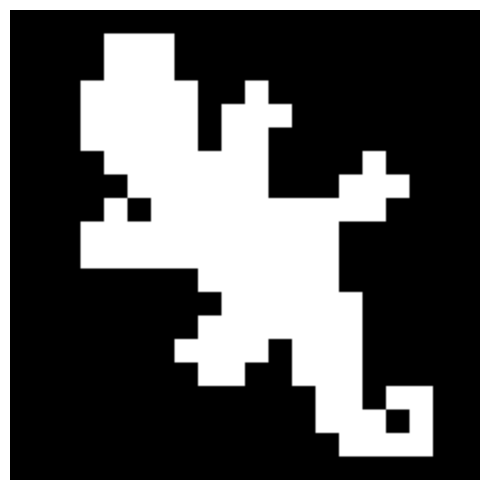

In [15]:
# @title Learning to Grow the lizard

# Outline of the lizard, creating a mask with 1 and 0 to use as target image
target_img = load_byte(lizard_byte, TARGET_SIZE_EMOJI) > 0.26
target_img = (target_img[..., 2] | target_img[..., 1] | target_img[..., 0]).astype(jnp.float32)
plot_show(zoom(target_img[..., None], 8))

In [17]:
# @title Learning to Grow the lizard 
hyperparams_growth = {'perceive': {}, 'update': {}}
hyperparams_growth['seed'] = 23
hyperparams_growth['lr'] = 0.06
hyperparams_growth['batch_size'] = 1
hyperparams_growth['num_epochs'] = 3500
hyperparams_growth['num_steps'] = 12
hyperparams_growth['channels'] = 128
hyperparams_growth['periodic'] = 1
hyperparams_growth['perceive']['n_kernels'] = 4
hyperparams_growth['perceive']['layers'] = [9, 8, 4, 2, 1]
hyperparams_growth['perceive']['connections'] = ['first_kernel','unique','unique','unique',]
init_growth = (hyperparams_growth['perceive']['n_kernels'] * hyperparams_growth['channels'] * hyperparams_growth['perceive']['layers'][-1] + hyperparams_growth['channels'])
hyperparams_growth['update']['layers'] = ([init_growth] + [512] * 8 + [256, hyperparams_growth['channels']])
hyperparams_growth['update']['connections'] = ['unique'] * len(hyperparams_growth['update']['layers'])
hyperparams_growth['async_training'] = False
hyperparams_growth['training'] = False
hyperparams_growth['periodic'] = True

# train_y = jnp.zeros(shape=(hyperparams['batch_size'],TARGET_SIZE_EMOJI,TARGET_SIZE_EMOJI,hyperparams['channels'],)).at[:, :, :, 0].set(target_img)
# train_x = jnp.zeros(shape=(hyperparams['batch_size'],TARGET_SIZE_EMOJI,TARGET_SIZE_EMOJI,hyperparams['channels'],)).at[:, TARGET_SIZE_EMOJI // 2, TARGET_SIZE_EMOJI // 2, :].set(1)

In [18]:
# @title base64 G image
'''
Importing the Multicolor G image in base64 format.
'''
TARGET_SIZE_G = 16
g_byte = b64decode("...")

(16, 16, 4)


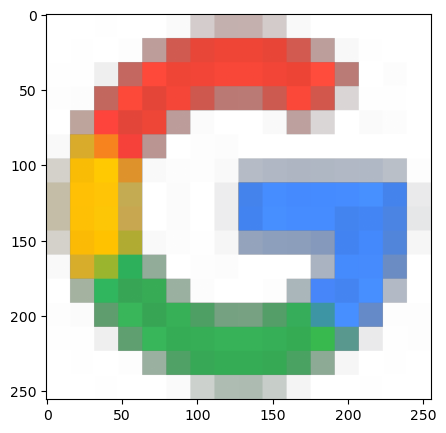

In [19]:
target_img_g_byte = load_byte(g_byte, TARGET_SIZE_G)
print(target_img_g_byte.shape)
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(zoom(target_img_g_byte, 16))

# Generating masks for distinct colors by analyzing the RGB channels of the G image
blue = (target_img_g_byte[:, :, 2] > 0.5).astype(jnp.float32)
yellow = (target_img_g_byte[:, :, 0] > 0.3) & (target_img_g_byte[:, :, 1] > 0.3)
red = (target_img_g_byte[:, :, 0] > 0.5) & (~yellow)
green = (target_img_g_byte[:, :, 1] > 0.6) & (~yellow)

In [2]:
# G image parameters
hyperparams_g_color = {'perceive': {}, 'update': {}}
hyperparams_g_color['seed'] = 23
hyperparams_g_color['lr'] = 0.06
hyperparams_g_color['batch_size'] = 1
hyperparams_g_color['num_epochs'] = 3000
hyperparams_g_color['num_steps'] = 15
hyperparams_g_color['channels'] = 64
hyperparams_g_color['periodic'] = 0
hyperparams_g_color['perceive']['n_kernels'] = 4
hyperparams_g_color['perceive']['layers'] = [9, 8, 4, 2]
hyperparams_g_color['perceive']['connections'] = ['first_kernel','unique', 'unique', 'unique',]
init_g_color = (hyperparams_g_color['perceive']['n_kernels'] * hyperparams_g_color['channels'] * hyperparams_g_color['perceive']['layers'][-1] + hyperparams_g_color['channels'])
hyperparams_g_color['update']['layers'] = ([init_g_color] + [512] * 8 + [256, 128, hyperparams_g_color['channels']])
hyperparams_g_color['update']['connections'] = ['unique'] * len(hyperparams_g_color['update']['layers'])
hyperparams_g_color['async_training'] = False
hyperparams_g_color['training'] = False
hyperparams_g_color['periodic'] = False

# train_y_g_color = jax.numpy.zeros(shape=(hyperparams['batch_size'],target_img_g_byte.shape[0],target_img_g_byte.shape[1],hyperparams['channels'],))
# train_y_g_color = train_y_g_color.at[0, :, :, 0].set(red | yellow)
# train_y_g_color = train_y_g_color.at[0, :, :, 1].set(green | yellow)
# train_y_g_color = train_y_g_color.at[0, :, :, 2].set(blue)

# train_x = jax.numpy.zeros((hyperparams['batch_size'],target_img_g_byte.shape[0],target_img_g_byte.shape[1],hyperparams['channels'],))

In [16]:
g_byte = b64decode("...")

In [3]:
def feature_dim_from_hyper(h):
    C = int(h["channels"])
    K = int(h["perceive"]["n_kernels"])
    S = int(h["perceive"]["layers"][-1])  # final perceive layer width
    F = C * (1 + K * S)
    return {"C": C, "K": K, "S": S, "F_update_in": F}

def set_update_input_dim(h):
    info = feature_dim_from_hyper(h)
    h = dict(h)  # shallow copy
    h["update"] = dict(h["update"])
    h["update"]["layers"] = list(h["update"]["layers"])
    h["update"]["layers"][0] = info["F_update_in"]
    return h, info

def assert_update_matches_perceive(h):
    info = feature_dim_from_hyper(h)
    got = int(h["update"]["layers"][0])
    if got != info["F_update_in"]:
        raise ValueError(f"update in_dim={got} but required={info['F_update_in']} "
                         f"(C={info['C']}, K={info['K']}, S={info['S']})")

print(feature_dim_from_hyper(hyperparams_g_color))
print(set_update_input_dim(hyperparams_g_color))
assert_update_matches_perceive(hyperparams_g_color)

{'C': 64, 'K': 4, 'S': 2, 'F_update_in': 576}
({'perceive': {'n_kernels': 4, 'layers': [9, 8, 4, 2], 'connections': ['first_kernel', 'unique', 'unique', 'unique']}, 'update': {'layers': [576, 512, 512, 512, 512, 512, 512, 512, 512, 256, 128, 64], 'connections': ['unique', 'unique', 'unique', 'unique', 'unique', 'unique', 'unique', 'unique', 'unique', 'unique', 'unique', 'unique']}, 'seed': 23, 'lr': 0.06, 'batch_size': 1, 'num_epochs': 3000, 'num_steps': 15, 'channels': 64, 'periodic': False, 'async_training': False, 'training': False}, {'C': 64, 'K': 4, 'S': 2, 'F_update_in': 576})
